### GNSS-InSAR Calibration Workflow

This notebook exemplifies how to use the Venti package to calibrate OPERA DISP-S1 displacement
products using GNSS reference data from the University of Nevada, Reno (UNR) grid timeseries.

Workflow steps:
1. Download GNSS stations within the InSAR scene bounds
2. Compute a GNSS LOS velocity or displacement field
3. Correct unwrapping errors relative to the GNSS reference
4. (Optional) Apply an event mask to prevent transient deformation from biasing calibration
5. Estimate and remove a long-wavelength calibration surface via windowed plane fitting

Two GNSS `grid_type` modes are supported:
- **`constant`** — fits a single GNSS velocity field and scales it per epoch
- **`variable`** — computes epoch-specific GNSS displacements

### Imports

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from venti.io.raster import read_geotiff, read_netcdf
from venti.workflow.calibration import CalibrationWorkflow
from venti.workflow.config import (
    AlgorithmParameters,
    CalibrationInputGroup,
    CalibrationOptions,
    PrimaryExecutable,
    ProcessingOptions,
    ProductPathGroup,
    RunConfig,
    VentiConfig,
    WorkerSettings,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(name)-20s | %(levelname)-8s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

In [2]:
%load_ext autoreload
%autoreload 2

### Input configuration

Set the paths and parameters for the dataset. All paths should point to existing files or directories.

In [3]:
# Input paths
input_dir       = Path("/u/aurora-r0/cabrera/opera_vlm/data/36540/disp")
los_file        = Path("/u/aurora-r0/cabrera/opera_vlm/data/36540/static_layer")
mask_file       = Path("/u/aurora-r0/cabrera/opera_vlm/data/36540/aligned_water_mask.tif")
output_dir      = Path("/u/aurora-r0/cabrera/opera_vlm/data/36540/venti_test")
tropo_dir       = None
# Directory containing per-epoch event mask GeoTIFFs produced by generate_event_mask.py.
# Set to None to skip event masking.
event_mask_dir  = None  # e.g. Path("/u/aurora-r0/cabrera/opera_vlm/data/36540/event_masks")

# Calibration parameters
grid_type               = "constant"   # "constant" (velocity) or "variable" (per-epoch)
reference_frame         = "IGS20"
downsample_factor       = 1
window_meters           = 30_000.0
posting_meters          = 30.0
start_year              = 2014.0
apply_unwrap_correction = True
recompute_gnss          = False         # True: always recompute; False: load cache if it exists

run_config = RunConfig(
    calibration_input_group=CalibrationInputGroup(
        input_files=input_dir,
        los_file=los_file,
        water_mask=mask_file,
        tropo_files=tropo_dir,
        event_mask_dir=event_mask_dir,
    ),
    product_path_group=ProductPathGroup(
        product_path=output_dir,
        scratch_path=output_dir / "scratch",
        sas_output_path=output_dir,
    ),
    primary_executable=PrimaryExecutable(product_type="CAL", workflow_name="calibrate"),
    worker_settings=WorkerSettings(gpu_enabled=False),
)

algorithm_params = AlgorithmParameters(
    processing_options=ProcessingOptions(cal_downsample_factor=downsample_factor),
    calibration_options=CalibrationOptions(
        grid_type=grid_type,
        reference_frame=reference_frame,
        starting_year=start_year,
        unwrap_error_correction=apply_unwrap_correction,
        window_size_meters=window_meters,
        posting_meters=posting_meters,
        recompute_gnss=recompute_gnss,
    ),
)

config = VentiConfig(run_config=run_config, algorithm_parameters=algorithm_params)
print(f"  grid_type      : {config.grid_settings.grid_type}")
print(f"  reference_frame: {config.grid_settings.reference_frame}")
print(f"  window         : {window_meters / 1e3:.0f} km")
print(f"  recompute_gnss : {recompute_gnss}")
print(f"  event_mask_dir : {event_mask_dir}")
print(f"  output_dir     : {output_dir}")

  grid_type      : constant
  reference_frame: IGS20
  window         : 30 km
  recompute_gnss : False
  event_mask_dir : None
  output_dir     : /u/aurora-r0/cabrera/opera_vlm/data/36540/venti_test


### Event mask (optional)

Transient deformation from earthquakes, volcanic unrest, or other discrete events can bias the
calibration surface if it is estimated over the whole scene. The event mask workflow removes this
bias by:

1. **Reading** a per-epoch event mask GeoTIFF (1 = valid, 0 = event region), produced by
   `generate_event_mask.py` from a GeoJSON of event polygons.
2. **Filling** the event-region pixels with nearest-valid-neighbor values so the calibration
   surface estimation has no data gaps.
3. **Fitting** the calibration surface on the filled displacement.
4. **Removing** the surface from the original (un-filled) displacement, preserving the
   event signal in the output.

To use event masking set `event_mask_dir` above to a directory containing the masks generated by
`generate_event_mask.py`. Each mask file must begin with the displacement file stem:

```
<disp_stem>_<geojson_stem>_mask.tif
```

Epochs with no matching mask file are calibrated normally. The cell below previews the mask for
the selected displacement file if one exists.

In [4]:
# Preview the event mask for the first displacement file (if a mask directory is configured).
# This cell is informational only; the mask is applied automatically during workflow.run_single().

from venti.spatial.interpolation import fill_masked_region

_disp_file = sorted(config.input_options.input_files.glob("*.nc"))[0]

if config.input_options.event_mask_dir is not None:
    _mask_matches = sorted(
        config.input_options.event_mask_dir.glob(f"{_disp_file.stem}_*mask.tif")
    )
    if _mask_matches:
        _event_mask_file = _mask_matches[0]
        print(f"Event mask : {_event_mask_file.name}")

        _em_data, _em_geo = read_geotiff(_event_mask_file)
        _event_mask = _em_data.astype(bool)
        n_event_px = int((~_event_mask).sum())
        n_total_px = _event_mask.size
        print(f"Event pixels: {n_event_px:,} / {n_total_px:,} ({100 * n_event_px / n_total_px:.2f} %)")

        # Read displacement to show fill effect
        _water_mask_data, _ = read_geotiff(config.input_options.water_mask)
        _water_mask = _water_mask_data.astype(bool)
        _disp_raw, _, _ = read_netcdf(_disp_file, variable="displacement")
        _disp_mm = np.where(_water_mask & ~np.isnan(_disp_raw), _disp_raw * 1000.0, np.nan)
        _disp_filled = fill_masked_region(_disp_mm, _event_mask)

        _vmax = np.nanpercentile(np.abs(_disp_mm), 98)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im0 = axes[0].imshow(_disp_mm, cmap="RdBu", vmin=-_vmax, vmax=_vmax)
        axes[0].set_title("InSAR displacement (mm)")

        # Overlay event region contour on displacement
        im1 = axes[1].imshow(_disp_mm, cmap="RdBu", vmin=-_vmax, vmax=_vmax)
        axes[1].contour(~_event_mask, levels=[0.5], colors="k", linewidths=1.5)
        axes[1].set_title("Event region (black outline)")

        im2 = axes[2].imshow(_disp_filled, cmap="RdBu", vmin=-_vmax, vmax=_vmax)
        axes[2].contour(~_event_mask, levels=[0.5], colors="k", linewidths=1.5)
        axes[2].set_title("Filled for calibration (mm)")

        for ax, im in zip(axes, [im0, im1, im2]):
            ax.set_xlabel("Column")
            ax.set_ylabel("Row")
            cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.08, fraction=0.046)
            cb.set_label("mm")
            cb.ax.tick_params(labelsize=7, rotation=30)

        plt.suptitle(_event_mask_file.name, fontsize=9)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No event mask found for {_disp_file.name} in {config.input_options.event_mask_dir}")
else:
    print("event_mask_dir is None — event masking disabled. Set it above to enable.")

event_mask_dir is None — event masking disabled. Set it above to enable.


### Run calibration workflow

`CalibrationWorkflow.run_single` calibrates a single specified displacement file:
1. Download GNSS stations and compute the LOS reference field
2. Compute average temporal coherence and auto-select the reference point
3. Correct unwrapping errors relative to the GNSS reference
4. If an event mask is found for this epoch: fill the event region with nearest valid neighbors
5. Fit and subtract a windowed calibration surface (using the filled displacement if masked)
6. Write the calibration surface GeoTIFF to `output_dir`

Set `disp_file` to the specific DISP NetCDF you want to calibrate.

In [5]:
# Pick the specific displacement file to calibrate
disp_file = sorted(config.input_options.input_files.glob("*.nc"))[0]

workflow = CalibrationWorkflow(config=config)
state = workflow.run_single(disp_file=disp_file)

print(f"files processed : {state.n_files_processed} / {state.n_files_total}")
print(f"files failed    : {state.n_files_failed}")
for f in state.output_files:
    print(f"  {f.name}")

2026-03-23 16:50:55 | venti.workflow.calibration | INFO     | Calibration workflow initialized
2026-03-23 16:50:55 | venti.workflow.calibration | INFO     | ============================================================
2026-03-23 16:50:55 | venti.workflow.calibration | INFO     | Starting Venti Single-File Calibration
2026-03-23 16:50:55 | venti.workflow.calibration | INFO     | ============================================================
2026-03-23 16:50:55 | venti.workflow.calibration | INFO     | Input file : /u/aurora-r0/cabrera/opera_vlm/data/36540/disp/OPERA_L3_DISP-S1_IW_F36540_VV_20160724T015809Z_20160805T015809Z_v1.0_20250408T163434Z.nc
2026-03-23 16:50:55 | venti.io.read        | INFO     | Reading NetCDF: /u/aurora-r0/cabrera/opera_vlm/data/36540/disp/OPERA_L3_DISP-S1_IW_F36540_VV_20160724T015809Z_20160805T015809Z_v1.0_20250408T163434Z.nc
2026-03-23 16:50:56 | venti.io.raster      | INFO     | Read NetCDF: /u/aurora-r0/cabrera/opera_vlm/data/36540/disp/OPERA_L3_DISP-S1_IW_F36

files processed : 1 / 1
files failed    : 0
  OPERA_L3_DISP-S1_IW_F36540_VV_20160724T015809Z_20160805T015809Z_v1.0_20250408T163434Z_calibration_surface_constant_igs20.tif


### Inspect calibration 

2026-03-23 16:53:17 | venti.io.raster      | INFO     | Read NetCDF: /u/aurora-r0/cabrera/opera_vlm/data/36540/disp/OPERA_L3_DISP-S1_IW_F36540_VV_20160724T015809Z_20160805T015809Z_v1.0_20250408T163434Z.nc, variable=displacement, shape=(7707, 9451)
2026-03-23 16:53:18 | venti.io.raster      | INFO     | Read GeoTIFF: /u/aurora-r0/cabrera/opera_vlm/data/36540/venti_test/OPERA_L3_DISP-S1_IW_F36540_VV_20160724T015809Z_20160805T015809Z_v1.0_20250408T163434Z_calibration_surface_constant_igs20.tif, shape=(7707, 9451)
2026-03-23 16:53:18 | venti.io.raster      | INFO     | Read GeoTIFF: /u/aurora-r0/cabrera/opera_vlm/data/36540/aligned_water_mask.tif, shape=(7707, 9451)
2026-03-23 16:53:18 | venti.workflow.utils | INFO     | Using existing average temporal_coherence: /u/aurora-r0/cabrera/opera_vlm/data/36540/venti_test/average_temporal_coherence.tif
2026-03-23 16:53:19 | venti.workflow.calibration | INFO     | Auto-selected reference point: (np.int64(2939), np.int64(7259))


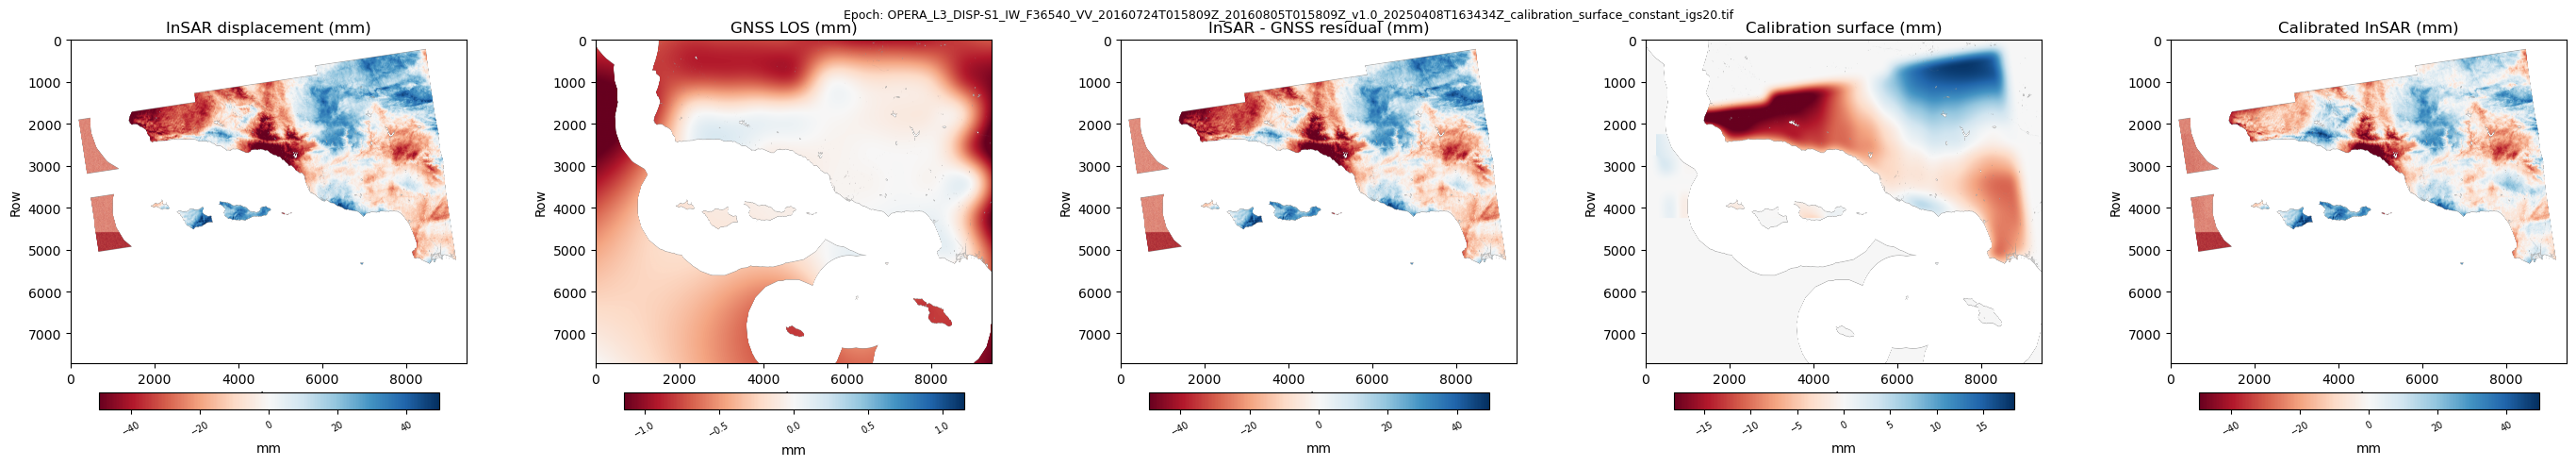

In [6]:
from venti.workflow.utils import get_file_dates

if not state.output_files:
    raise RuntimeError("No output files produced — check the workflow above.")

out_file = state.output_files[0]
in_file  = disp_file

# Read input displacement and calibration surface
disp_m, _, _geo    = read_netcdf(in_file, variable="displacement")
cal_surface_m, _geo = read_geotiff(out_file)

mask_data, _ = read_geotiff(config.input_options.water_mask)
mask = mask_data.astype(bool)

disp_mm        = np.where(mask, disp_m * 1000.0, np.nan)
cal_surface_mm = np.where(mask, cal_surface_m.squeeze() * 1000.0, np.nan)

# Mirror the reference-point subtraction applied inside process_displacement_file
refy_disp, refx_disp = workflow.find_reference_point(mask)
disp_mm = disp_mm - disp_mm[refy_disp, refx_disp]

# Load GNSS LOS from the workflow cache (mm/yr for constant, mm for variable)
output_dir = config.run_config.product_path_group.product_path
ref_date, sec_date = get_file_dates(in_file)

if config.grid_settings.grid_type == "constant":
    gnss_vel = np.load(output_dir / "gnss_los_velocity.npy")  # mm/yr
    gnss_los_mm = gnss_vel * (sec_date - ref_date)
else:
    gnss_los_mm = np.load(
        output_dir / f"gnss_los_disp_{ref_date:.4f}_{sec_date:.4f}.npy"
    )

# Apply reference-point subtraction (mirrors the workflow convention)
gnss_los_mm -= gnss_los_mm[refy_disp, refx_disp]
gnss_los_mm = np.where(mask, gnss_los_mm, np.nan)

# Derived fields: residual before calibration and the calibrated displacement
residual_mm  = disp_mm - gnss_los_mm
corrected_mm = disp_mm - cal_surface_mm

_vmax  = np.nanpercentile(np.abs(disp_mm), 98)
_gmax  = np.nanpercentile(np.abs(gnss_los_mm), 98)
_rvmax = np.nanpercentile(np.abs(residual_mm), 98)
_csmax = np.nanpercentile(np.abs(cal_surface_mm), 98)

fig, axes = plt.subplots(1, 5, figsize=(28, 5))

panels = [
    (axes[0], disp_mm,        _vmax,  "InSAR displacement (mm)"),
    (axes[1], gnss_los_mm,    _gmax,  "GNSS LOS (mm)"),
    (axes[2], residual_mm,    _rvmax, "InSAR - GNSS residual (mm)"),
    (axes[3], cal_surface_mm, _csmax, "Calibration surface (mm)"),
    (axes[4], corrected_mm,   _vmax,  "Calibrated InSAR (mm)"),
]

for ax, data, vmax, title in panels:
    im = ax.imshow(data, cmap="RdBu", vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.08, fraction=0.046)
    cb.set_label("mm")
    cb.ax.tick_params(labelsize=7, rotation=30)

plt.suptitle(f"Epoch: {out_file.name}", fontsize=9)
plt.tight_layout()
plt.show()

### Process Summary

In [7]:
print("Calibration complete")
print(f"  grid_type        : {config.grid_settings.grid_type}")
print(f"  reference_frame  : {config.grid_settings.reference_frame}")
print(f"  window           : {window_meters / 1e3:.0f} km")
print(f"  downsample       : {downsample_factor}x")
print(f"  files processed  : {state.n_files_processed} / {state.n_files_total}")
print(f"  output_dir       : {output_dir}")

Calibration complete
  grid_type        : constant
  reference_frame  : IGS20
  window           : 30 km
  downsample       : 1x
  files processed  : 1 / 1
  output_dir       : /u/aurora-r0/cabrera/opera_vlm/data/36540/venti_test
